# Análise de Vendedores com Alta Quantidade de Vendas e Baixa Avaliação

Este notebook investiga vendedores da base Olist com volume relevante de pedidos e desempenho baixo de satisfação.
O foco é entender o peso desse grupo no negócio por meio de métricas de pedidos, receita e participação de vendedores.

**Escopo desta versão:** preparação da base, segmentação de detratores e resumo quantitativo (com visualizações).

**Fonte dos dados:** [Olist E-Commerce Public Dataset - Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

**Fluxo da análise**
1. Importação das bibliotecas e carregamento das tabelas principais.
2. Limpeza mínima por domínio (pedidos, reviews, itens e vendedores).
3. Construção da base analítica por vendedor.
4. Segmentação em detratores vs. não detratores.
5. Consolidação do impacto percentual em pedidos, receita e base de sellers.

---
## 1. Importação e carregamento das tabelas

Nesta etapa, importamos as bibliotecas e carregamos as tabelas essenciais para a análise de desempenho dos vendedores.
Os arquivos CSV estão no diretório `data/`.

- **order_items**: relacionamento entre pedidos, produtos e vendedores.
- **order_reviews**: notas de satisfação dos clientes por pedido.
- **orders**: status e informações de datas dos pedidos.
- **sellers**: dados cadastrais de localização dos vendedores.
- **products**: metadados de produtos usados em extensões futuras da análise.

In [40]:
import pandas as pd
from pathlib import Path

# DATA_DIR aponta para a pasta onde estão os CSVs do projeto
# Se os arquivos estiverem na pasta correta, basta clicar em "Run" nesta célula
DATA_DIR = Path("data")

# Carregamento das tabelas principais da análise
reviews = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv")
order_items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
sellers = pd.read_csv(DATA_DIR / "olist_sellers_dataset.csv")
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")

# Conferência rápida: quantas linhas foram lidas em cada tabela
# Isso ajuda a confirmar que o carregamento funcionou
print('Linhas carregadas:')
print(f'  orders:      {len(orders):>7,}')
print(f'  order_items: {len(order_items):>7,}')
print(f'  reviews:     {len(reviews):>7,}')
print(f'  products:    {len(products):>7,}')
print(f'  sellers:     {len(sellers):>7,}')

Linhas carregadas:
  orders:       99,441
  order_items: 112,650
  reviews:      99,224
  products:     32,951
  sellers:       3,095


---
## 2. Limpeza das tabelas

A limpeza é aplicada separadamente por tabela para facilitar rastreabilidade.
Cada regra abaixo busca reduzir ruído sem perder representatividade estatística.

- **orders**: mantém apenas pedidos entregues com data de entrega válida.
- **reviews**: mantém notas válidas e remove duplicidade de `order_id`.
- **order_items**: remove itens sem `seller_id` e com preço inválido.
- **sellers**: mantém apenas registros com cidade e estado preenchidos.

In [41]:
# -------------------- Limpeza da tabela de pedidos (orders) --------------------
# Objetivo: manter apenas pedidos realmente entregues, pois só eles fazem sentido
# para análise de satisfação do cliente.

# 1) Filtra apenas pedidos com status "delivered" (entregue)
orders_clean = orders[orders['order_status'] == 'delivered'].copy()

# 2) Remove pedidos sem data de entrega ao cliente
# Sem essa data, não conseguimos confirmar a entrega de forma confiável
orders_clean = orders_clean.dropna(subset=['order_delivered_customer_date'])

# 3) Mostra o efeito da limpeza
print(f'orders original:  {len(orders):,} linhas')
print(f'orders limpo:     {len(orders_clean):,} linhas')

orders original:  99,441 linhas
orders limpo:     96,470 linhas


In [42]:
# ------------------- Limpeza da tabela de avaliações (reviews) -------------------
# Objetivo: garantir que a nota usada na média do vendedor seja válida e sem repetição.

# 1) Remove linhas sem nota de avaliação
reviews_clean = reviews.dropna(subset=['review_score']).copy()

# 2) Mantém apenas notas dentro da escala oficial (1 a 5)
reviews_clean = reviews_clean[reviews_clean['review_score'].between(1, 5)]

# 3) Remove duplicidades de order_id
# Se houver mais de uma avaliação para o mesmo pedido, mantemos a primeira
reviews_clean = reviews_clean.drop_duplicates(subset='order_id', keep='first')

# 4) Mostra o efeito da limpeza
print(f'reviews original: {len(reviews):,} linhas')
print(f'reviews limpo:    {len(reviews_clean):,} linhas')

reviews original: 99,224 linhas
reviews limpo:    98,673 linhas


In [43]:
# ------------------- Limpeza da tabela de itens do pedido -------------------
# Objetivo: manter itens que permitem identificar o vendedor e calcular receita.

# 1) Remove itens sem seller_id (sem vendedor identificado)
items_clean = order_items.dropna(subset=['seller_id']).copy()

# 2) Remove itens com preço zero ou negativo (inconsistentes para análise de receita)
items_clean = items_clean[items_clean['price'] > 0]

# 3) Mostra o efeito da limpeza
print(f'order_items original: {len(order_items):,} linhas')
print(f'order_items limpo:    {len(items_clean):,} linhas')

order_items original: 112,650 linhas
order_items limpo:    112,650 linhas


In [44]:
# ------------------- Limpeza da tabela de vendedores (sellers) -------------------
# Objetivo: manter dados mínimos de localização para permitir análises por região e garantir 
# que todos os vendedores tenham informações relevantes para análises posteriores.

# Remove vendedores sem cidade ou estado preenchidos
sellers_clean = sellers.dropna(subset=['seller_city', 'seller_state']).copy()

# Mostra o efeito da limpeza
print(f'sellers original: {len(sellers):,} linhas')
print(f'sellers limpo:    {len(sellers_clean):,} linhas')

sellers original: 3,095 linhas
sellers limpo:    3,095 linhas


---
## 3. Montagem da base analítica por vendedor

As bases limpas são cruzadas para formar uma visão consolidada por `seller_id`.

**Métricas calculadas por vendedor:**
- `total_pedidos`: quantidade de pedidos únicos entregues.
- `media_nota`: média do `review_score`.
- `receita_total`: soma de `price` dos itens vendidos.

Resultado desta etapa: dataframe `seller_stats`, base principal para a segmentação de risco.

In [45]:
# ------------------- Montagem da base analitica por vendedor -------------------
# Nesta celula, juntamos tabelas diferentes para chegar a uma visao unica por seller_id.

# 1) Mantem apenas itens que pertencem a pedidos entregues
# (join interno: so fica o que existe em ambas as tabelas)
items_delivered = items_clean.merge(
    orders_clean[['order_id']],
    on='order_id',
    how='inner'
)

# 2) Cria uma base de satisfacao por pedido e vendedor.
# Como um pedido pode ter mais de um item, usamos drop_duplicates para garantir
# que cada avaliacao conte apenas uma vez para cada vendedor dentro do pedido.
seller_orders = items_delivered[['order_id', 'seller_id']].drop_duplicates()

items_with_review = seller_orders.merge(
    reviews_clean[['order_id', 'review_score']],
    on='order_id',
    how='left'  # Pedidos sem review permanecem na base; a media ignora NaN
)

# 3) Calcula pedidos e satisfacao por vendedor.
# - total_pedidos: quantidade de pedidos unicos
# - media_nota: media das avaliacoes por pedido, sem repetir nota por item
seller_satisfaction = (
    items_with_review
    .groupby('seller_id')
    .agg(
        total_pedidos=('order_id', 'nunique'),
        media_nota=('review_score', 'mean')
    )
    .reset_index()
)

# 4) Calcula receita separadamente, mantendo a soma item a item.
# Para receita, faz sentido usar a tabela de itens porque cada item possui preco proprio.
seller_revenue = (
    items_delivered
    .groupby('seller_id')
    .agg(receita_total=('price', 'sum'))
    .reset_index()
)

# 5) Junta satisfacao/pedidos com receita na base final por vendedor.
seller_stats = seller_satisfaction.merge(
    seller_revenue,
    on='seller_id',
    how='left'
)

# Conferencia: quantos vendedores ficaram na base final
print(f'Total de vendedores com dados: {len(seller_stats):,}')

# Mostra as primeiras linhas para validar estrutura e colunas
seller_stats.head()


Total de vendedores com dados: 2,970


,seller_id,total_pedidos,media_nota,receita_total
0,0015a82c2db000af6aaaf3ae2ecb0532,3,3.666667,2685.00
1,001cca7ae9ae17fb1caed9dfb1094831,195,4.062500,24487.03
2,002100f778ceb8431b7a1020ff7ab48f,50,3.960000,1216.60
3,003554e2dce176b5555353e4f3555ac8,1,5.000000,120.00
4,004c9cd9d87a3c30c522c48c4fc07416,156,4.136364,19569.73


---
## 4. Segmentação de detratores e diagnóstico inicial

Nesta etapa, classificamos os vendedores por nota média e comparamos o grupo de detratores com os demais.

**Regra adotada nesta versão:**
- `detrator = True` quando `media_nota <= 3`.

In [46]:
# ------------------- Segmentação de vendedores -------------------
# Regra usada: vendedor com média de nota <= 3 é classificado como detrator.

# 1) Cria coluna booleana (True/False) para identificar detratores
seller_stats['detrator'] = seller_stats['media_nota'] <= 3

# 2) Separa em dois grupos para comparação
# .copy() evita alertas de modificação indireta em pandas
detratores = seller_stats[seller_stats['detrator']].copy()
nao_detratores = seller_stats[~seller_stats['detrator']].copy()

# 3) Mostra quantos vendedores existem em cada grupo
print('Distribuição de vendedores por grupo:')
print(seller_stats['detrator'].value_counts())

# 4) Resumo estatístico do grupo detrator
# Importante para leigos: na linha "count", o valor indica quantos vendedores
# entraram nesse grupo para cada métrica analisada.
print('\nResumo descritivo - detratores:')
display(detratores[['total_pedidos', 'media_nota', 'receita_total']].describe())

# 5) Resumo estatístico do grupo não detrator
print('\nResumo descritivo - não detratores:')
display(nao_detratores[['total_pedidos', 'media_nota', 'receita_total']].describe())

Distribuição de vendedores por grupo:
detrator
False    2728
True      242
Name: count, dtype: int64

Resumo descritivo - detratores:


,total_pedidos,media_nota,receita_total
count,242.000000,242.000000,242.000000
mean,3.681818,2.202579,1000.193802
std,13.870848,0.828586,3729.892131
min,1.000000,1.000000,6.900000
25%,1.000000,1.000000,75.000000
50%,2.000000,2.500000,173.995000
75%,3.000000,3.000000,581.000000
max,187.000000,3.000000,38990.720000



Resumo descritivo - não detratores:


,total_pedidos,media_nota,receita_total
count,2728.000000,2723.000000,2728.000000
mean,35.527859,4.350739,4757.405436
std,109.529728,0.469506,14449.498342
min,1.000000,3.025316,6.500000
25%,3.000000,4.000000,269.675000
50%,8.000000,4.333333,989.540000
75%,26.000000,4.750000,3772.282500
max,1819.000000,5.000000,226987.930000


In [47]:
# ------------------- Resumo executivo do impacto -------------------
# Aqui transformamos a segmentação em uma tabela de impacto para narrativa executiva.

# 1) Soma métricas por grupo (detrator x não detrator)
final_detratores = (
    seller_stats
    .groupby('detrator', as_index=False)
    .agg(
        total_pedidos=('total_pedidos', 'sum'),
        receita_total=('receita_total', 'sum'),
        vendedores=('seller_id', 'count')
    )
)

# 2) Calcula participação percentual em receita
# Fórmula: (valor do grupo / valor total) * 100
total_receita = final_detratores['receita_total'].sum()
final_detratores['%Receita_total'] = (final_detratores['receita_total'] / total_receita) * 100

# 3) Calcula participação percentual em pedidos
total_pedido = final_detratores['total_pedidos'].sum()
final_detratores['%Pedido_total'] = (final_detratores['total_pedidos'] / total_pedido) * 100

# 4) Calcula participação percentual na quantidade de vendedores
total_vendedores = final_detratores['vendedores'].sum()
final_detratores['%Vendedor_total'] = (final_detratores['vendedores'] / total_vendedores) * 100

# 5) Arredonda resultados para facilitar leitura em apresentação
final_detratores = final_detratores.round({
    'receita_total': 2,
    '%Receita_total': 2,
    '%Pedido_total': 2,
    '%Vendedor_total': 2,
})

# 6) Exibe a tabela final consolidada
final_detratores

,detrator,total_pedidos,receita_total,vendedores,%Receita_total,%Pedido_total,%Vendedor_total
0,False,96920,12978202.03,2728,98.17,99.09,91.85
1,True,891,242046.90,242,1.83,0.91,8.15


---

## 5. Leitura executiva dos resultados

Nesta etapa, a análise deixa de olhar vendedor por vendedor e passa a consolidar os resultados em uma visão executiva. O objetivo é transformar a segmentação criada anteriormente em números fáceis de interpretar para tomada de decisão.

A tabela `final_detratores` resume três perguntas principais:

1. Qual a participação dos detratores no volume total de pedidos (`%Pedido_total`)?
2. Qual a participação dos detratores na receita total (`%Receita_total`)?
3. Qual o peso dos detratores dentro da base de vendedores (`%Vendedor_total`)?

Essa consolidação é importante porque permite comparar risco e relevância econômica. Assim, o relatório consegue mostrar se o problema está ligado a volume, receita ou reputação. A partir dessa leitura, os gráficos e recomendações deixam de ser apenas descritivos e passam a apoiar uma decisão de gestão sobre permanência, alerta ou remoção de vendedores.

---

## 6. Preparação dos indicadores para os gráficos

Esta seção prepara os indicadores que serão usados nos gráficos do relatório final. A ideia é deixar os dados prontos em tabelas simples, evitando repetir cálculos em cada visualização.

Os indicadores foram separados em blocos para facilitar a revisão pelo grupo:

- tabela executiva por grupo: compara detratores e não detratores;
- faixas de satisfação: separa vendedores sem avaliação, detratores, atenção e saudáveis;
- médias de satisfação: mostra o efeito dos detratores na nota geral;
- formatações: padroniza porcentagens, valores monetários e cores dos gráficos.

Um ponto metodológico importante é que a base pública da Olist não possui uma pergunta formal de NPS. Por isso, a análise usa a média de `review_score` como uma proxy de satisfação. A regra adotada é simples e transparente: vendedores com `media_nota <= 3` são classificados como detratores.

Essa preparação ajuda a manter o notebook reprodutível e facilita a conferência dos números usados no documento final.

In [48]:
# ------------------- Configuração dos gráficos -------------------
# Esta célula centraliza imports e funções de formatação.
# Os gráficos são gerados e exibidos somente dentro do notebook.

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Paleta simples e consistente:
# azul = grupo saudável/não detrator, vermelho = detrator,
# amarelo = atenção, cinza = sem avaliação, verde = saudável.
COLORS = {
    'Não detratores (> 3)': '#3E7CB1',
    'Detratores (<= 3)': '#D95F4A',
    'Sem avaliação': '#8A8F98',
    'Atenção (> 3 e <= 4)': '#E0A33A',
    'Saudáveis (> 4)': '#2E8B57',
}

plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 10,
    'axes.titlesize': 14,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

def fmt_int(value):
    return f'{int(round(value)):,}'.replace(',', '.')

def fmt_pct(value):
    return f'{value:.2f}%'.replace('.', ',')

def fmt_money(value):
    return 'R$ ' + fmt_int(value)

def fmt_money_m(value):
    return f'R$ {value / 1_000_000:.2f} mi'.replace('.', ',')

def add_footer(fig):
    fig.text(0.01, 0.01, 'Fonte: Base pública Olist | Análise dos autores', fontsize=8, color='#637083')

### 6.1 Tabela executiva por grupo

Aqui os vendedores são consolidados em dois grupos: detratores e não detratores. Essa tabela resume pedidos, receita e quantidade de vendedores por grupo.

O objetivo é criar uma base única para responder perguntas executivas, como: qual grupo concentra a maior parte da receita, qual grupo representa maior volume de pedidos e qual é o peso dos detratores dentro da base.

Essa tabela alimenta os gráficos de participação, receita total, pedidos entregues e receita média por vendedor.

In [49]:
# ------------------- Indicadores por grupo -------------------
# Esta célula transforma a base por vendedor em uma tabela resumida para leitura executiva.
# A ideia é comparar detratores e não detratores usando sempre os mesmos indicadores:
# quantidade de pedidos, receita total e quantidade de vendedores.

# Cria uma coluna textual para facilitar leitura em tabelas e gráficos.
# False = vendedor acima da faixa crítica; True = vendedor detrator.
seller_stats['grupo_binario'] = seller_stats['detrator'].map({
    False: 'Não detratores (> 3)',
    True: 'Detratores (<= 3)'
})

# Agrupa os vendedores por classificação e soma os principais indicadores.
# total_pedidos: mostra o peso operacional de cada grupo.
# receita_total: mostra a relevância financeira de cada grupo.
# vendedores: mostra o tamanho do grupo dentro da base.
resumo_grupos = (
    seller_stats
    .groupby('grupo_binario', as_index=False)
    .agg(
        total_pedidos=('total_pedidos', 'sum'),
        receita_total=('receita_total', 'sum'),
        vendedores=('seller_id', 'count')
    )
)

# Calcula as participações percentuais para comparar grupos de tamanhos diferentes.
# Essas colunas são usadas diretamente nos rótulos e interpretações dos gráficos.
resumo_grupos['% Receita'] = resumo_grupos['receita_total'] / resumo_grupos['receita_total'].sum() * 100
resumo_grupos['% Pedidos'] = resumo_grupos['total_pedidos'] / resumo_grupos['total_pedidos'].sum() * 100
resumo_grupos['% Vendedores'] = resumo_grupos['vendedores'] / resumo_grupos['vendedores'].sum() * 100

# A receita média por vendedor mostra eficiência individual média de cada grupo.
resumo_grupos['receita_media_vendedor'] = resumo_grupos['receita_total'] / resumo_grupos['vendedores']

# Ordena para deixar o grupo saudável primeiro e os detratores em segundo.
# Isso padroniza a ordem dos gráficos e facilita comparação visual.
resumo_grupos = (
    resumo_grupos
    .set_index('grupo_binario')
    .loc[['Não detratores (> 3)', 'Detratores (<= 3)']]
    .reset_index()
)

resumo_grupos.round(2)

,grupo_binario,total_pedidos,receita_total,vendedores,% Receita,% Pedidos,% Vendedores,receita_media_vendedor
0,Não detratores (> 3),96920,12978202.03,2728,98.17,99.09,91.85,4757.41
1,Detratores (<= 3),891,242046.90,242,1.83,0.91,8.15,1000.19


### 6.2 Distribuição por faixas de satisfação

A separação entre detratores e não detratores ajuda na leitura inicial, mas ainda é limitada para recomendação. Por isso, a base também foi dividida em quatro faixas de ação.

- **Sem avaliação**: vendedores sem nota suficiente para leitura de satisfação.
- **Detratores**: vendedores com média menor ou igual a 3, tratados como risco crítico.
- **Atenção**: vendedores com média acima de 3 e até 4, que precisam de acompanhamento.
- **Saudáveis**: vendedores com média acima de 4, que sustentam a boa experiência.

Essa divisão aproxima a análise da decisão prática. Em vez de aplicar a mesma ação para todos, a Olist pode definir tratamentos diferentes para cada perfil.

In [50]:
# ------------------- Faixas de satisfação -------------------
# Esta célula cria grupos de ação, indo além da divisão simples entre detrator e não detrator.
# O objetivo é apoiar recomendações diferentes para perfis diferentes de vendedores.

# Incluímos todos os vendedores da tabela sellers_clean para identificar também quem ficou sem avaliação.
# O left join mantém vendedores que existem no cadastro, mesmo que não apareçam na base consolidada com nota.
seller_all = sellers_clean[['seller_id']].drop_duplicates().merge(seller_stats, on='seller_id', how='left')

# Função de classificação por faixa de satisfação.
# Sem avaliação: não há nota suficiente para leitura de qualidade.
# Detratores: média <= 3, grupo crítico para governança.
# Atenção: média entre 3 e 4, grupo que precisa de acompanhamento preventivo.
# Saudáveis: média acima de 4, grupo que sustenta a boa experiência.
def classificar_faixa(media_nota):
    if pd.isna(media_nota):
        return 'Sem avaliação'
    if media_nota <= 3:
        return 'Detratores (<= 3)'
    if media_nota <= 4:
        return 'Atenção (> 3 e <= 4)'
    return 'Saudáveis (> 4)'

# Aplica a função para cada vendedor e cria a coluna de faixa de satisfação.
seller_all['faixa_satisfacao'] = seller_all['media_nota'].apply(classificar_faixa)

# Conta quantos vendedores existem em cada faixa.
# Essa tabela alimenta o gráfico de distribuição por faixa de satisfação.
faixa_satisfacao = (
    seller_all
    .groupby('faixa_satisfacao', as_index=False)
    .agg(vendedores=('seller_id', 'count'))
)

# Ordena as faixas em ordem lógica de decisão: desconhecido, crítico, atenção e saudável.
ordem_faixas = ['Sem avaliação', 'Detratores (<= 3)', 'Atenção (> 3 e <= 4)', 'Saudáveis (> 4)']
faixa_satisfacao = (
    faixa_satisfacao
    .set_index('faixa_satisfacao')
    .loc[ordem_faixas]
    .reset_index()
)

faixa_satisfacao

,faixa_satisfacao,vendedores
0,Sem avaliação,130
1,Detratores (<= 3),242
2,Atenção (> 3 e <= 4),767
3,Saudáveis (> 4),1956


### 6.3 Médias de satisfação com e sem detratores

Esta etapa mede o impacto dos vendedores detratores na média geral de satisfação. Para isso, são calculadas duas visões.

A primeira é a **média por vendedor**, que considera cada parceiro como uma unidade de decisão. Essa visão é mais adequada para governança, porque a empresa decide se acompanha, recupera ou remove vendedores individualmente.

A segunda é a **média por avaliação/pedido**, que pondera o impacto pelo volume de avaliações. Essa visão ajuda a entender o efeito dos detratores no conjunto total de experiências registradas.

O relatório usa a média por vendedor no gráfico principal, pois o foco da análise é a gestão da base de parceiros.

In [51]:
# ------------------- Média com e sem detratores -------------------
# Esta célula calcula o efeito dos detratores na satisfação geral.
# Mantemos duas visões: por vendedor e por avaliação/pedido.

# Média simples das médias por vendedor.
# Essa visão trata cada vendedor como uma unidade de governança.
media_vendedor_com_detratores = seller_stats['media_nota'].mean()
media_vendedor_sem_detratores = seller_stats.loc[~seller_stats['detrator'], 'media_nota'].mean()

# Lista de vendedores detratores para remover suas avaliações na visão ponderada por pedido.
detrator_sellers = set(seller_stats.loc[seller_stats['detrator'], 'seller_id'])

# Média de todas as avaliações registradas.
# Essa visão considera o volume de avaliações/pedidos, não apenas a média por vendedor.
media_avaliacao_com_detratores = items_with_review['review_score'].mean()
media_avaliacao_sem_detratores = (
    items_with_review
    .loc[~items_with_review['seller_id'].isin(detrator_sellers), 'review_score']
    .mean()
)

print('Média por vendedor com detratores:', round(media_vendedor_com_detratores, 2))
print('Média por vendedor sem detratores:', round(media_vendedor_sem_detratores, 2))
print('Média por avaliação com detratores:', round(media_avaliacao_com_detratores, 2))
print('Média por avaliação sem detratores:', round(media_avaliacao_sem_detratores, 2))

Média por vendedor com detratores: 4.18
Média por vendedor sem detratores: 4.35
Média por avaliação com detratores: 4.14
Média por avaliação sem detratores: 4.15


---

## 7. Gráficos executivos

Os gráficos desta seção transformam os indicadores preparados anteriormente em uma narrativa visual. Cada gráfico responde uma pergunta específica do relatório e ajuda a sustentar a recomendação final.

A lógica dos gráficos é mostrar que os detratores existem, são mensuráveis e representam um risco relevante para a confiança na marca, mesmo sem concentrarem a maior parte da receita ou dos pedidos.

As cores foram mantidas de forma consistente ao longo do notebook: azul para vendedores saudáveis ou não detratores, vermelho para detratores, amarelo para atenção, cinza para sem avaliação e verde para saudáveis na análise por faixa.

### 7.1 Gráfico 1 - Participação dos vendedores por grupo

Pergunta respondida: **qual é a participação dos vendedores detratores dentro da base?**

Este gráfico dimensiona o problema em quantidade de parceiros. Ele mostra quantos vendedores estão no grupo crítico e quantos estão fora dele. A leitura é importante porque indica se a ação recomendada precisa ser ampla para toda a base ou focada em um grupo específico.

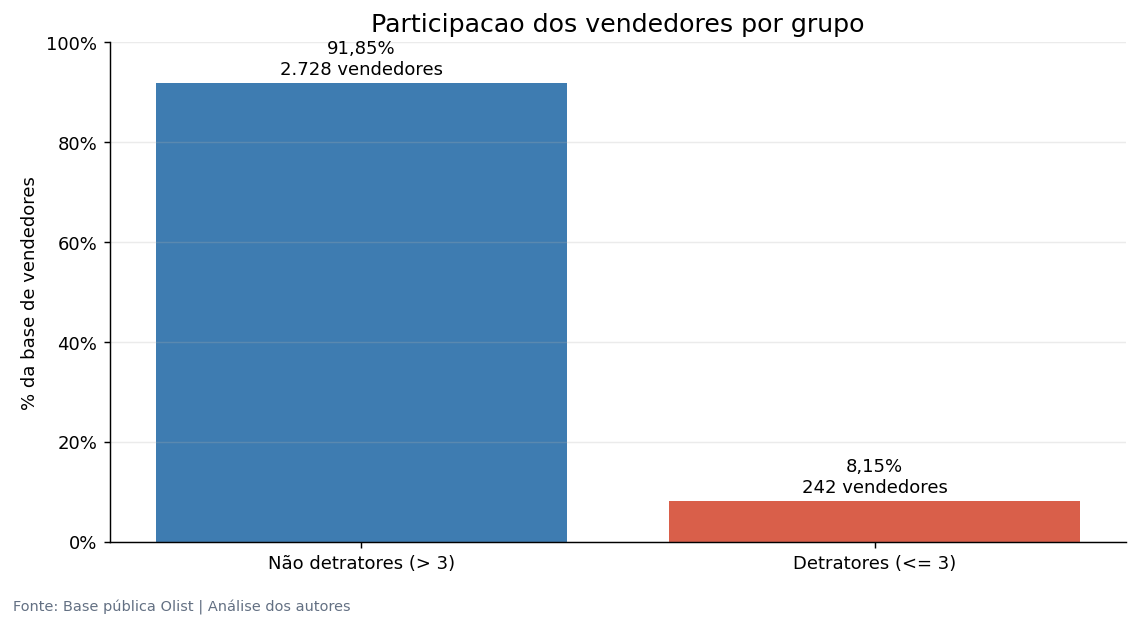

In [52]:
# Grafico 1: mostra a participacao dos vendedores por grupo.
# Usamos barras verticais para manter consistencia com os demais graficos do relatorio.
fig, ax = plt.subplots(figsize=(8.8, 4.8))
labels = resumo_grupos['grupo_binario']
values = resumo_grupos['% Vendedores']

bars = ax.bar(labels, values, color=[COLORS[label] for label in labels])
ax.set_title('Participacao dos vendedores por grupo')
ax.set_ylabel('% da base de vendedores')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis='y', alpha=0.25)

# Rotulo com percentual e quantidade absoluta para dimensionar o problema.
for bar, pct, vendedores in zip(bars, values, resumo_grupos['vendedores']):
    label = fmt_pct(pct) + chr(10) + fmt_int(vendedores) + ' vendedores'
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        label,
        ha='center',
        va='bottom'
    )

add_footer(fig)
fig.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()


### 7.2 Gráfico 2 - Comparação da Receita Total por Tipo de Parceiro

Pergunta respondida: **quanto os parceiros detratores representam em receita total na comparação com os parceiros saudáveis?**

Este gráfico compara a receita gerada por parceiros saudáveis e detratores. Ele ajuda a avaliar se o grupo crítico possui grande dependência financeira para a Olist. A leitura esperada é mostrar que o risco dos detratores está mais ligado à reputação e à confiança do que ao volume de receita entregue.

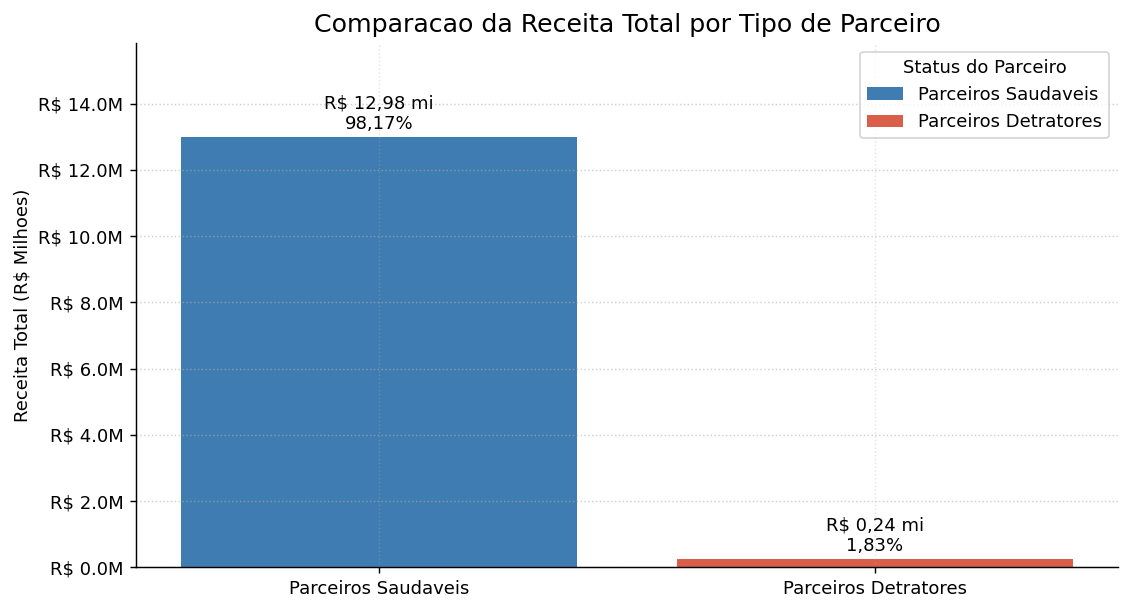

In [53]:
# Grafico 2: compara a receita total por tipo de parceiro.
# A visualizacao ajuda a mostrar se os detratores sao financeiramente relevantes.
fig, ax = plt.subplots(figsize=(8.8, 4.8))

# Cria nomes mais executivos para o grafico, sem alterar os grupos originais da analise.
plot_data = resumo_grupos.copy()
plot_data['tipo_parceiro'] = plot_data['grupo_binario'].map({
    'N\u00e3o detratores (> 3)': 'Parceiros Saudaveis',
    'Detratores (<= 3)': 'Parceiros Detratores',
})

# Usa a mesma paleta definida no notebook para manter consistencia visual.
plot_data['cor'] = plot_data['grupo_binario'].map(COLORS)

# Garante a ordem de leitura: saudaveis primeiro, detratores depois.
plot_data = plot_data.set_index('tipo_parceiro').loc[
    ['Parceiros Saudaveis', 'Parceiros Detratores']
].reset_index()

labels = plot_data['tipo_parceiro']
values = plot_data['receita_total']
colors = plot_data['cor']

bars = ax.bar(labels, values, color=colors)

ax.set_title('Comparacao da Receita Total por Tipo de Parceiro')
ax.set_ylabel('Receita Total (R$ Milhoes)')
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda value, _: f'R$ {value / 1_000_000:.1f}M')
)
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.grid(axis='x', linestyle=':', alpha=0.35)
ax.set_ylim(0, values.max() * 1.22)

# Mostra valor absoluto e participacao percentual de receita acima de cada barra.
for bar, value, pct in zip(bars, values, plot_data['% Receita']):
    label = fmt_money_m(value) + chr(10) + fmt_pct(pct)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + values.max() * 0.01,
        label,
        ha='center',
        va='bottom',
        fontsize=10,
    )

ax.legend(bars, labels, title='Status do Parceiro', loc='upper right')
fig.tight_layout()
plt.show()


### 7.3 Gráfico 3 - Pedidos entregues por grupo

Pergunta respondida: **quanto os detratores representam no volume de pedidos entregues?**

Este gráfico mostra a participação dos detratores no volume operacional. A intenção é verificar se esse grupo concentra muitos pedidos ou se o problema está mais relacionado à qualidade da experiência entregue. Por isso, o rótulo do gráfico destaca apenas a porcentagem, deixando a comparação mais direta para a leitura executiva.

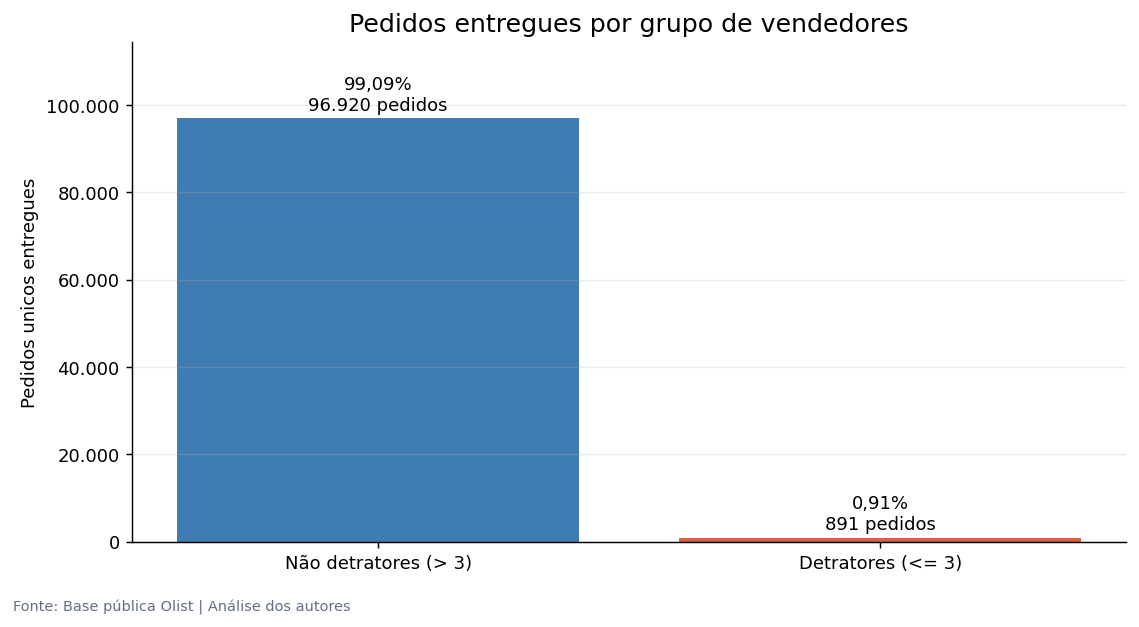

In [54]:
# Grafico 3: compara o volume de pedidos entregues por grupo.
# O objetivo e mostrar se os detratores concentram ou nao uma parte relevante da operacao.
fig, ax = plt.subplots(figsize=(8.8, 4.8))
labels = resumo_grupos['grupo_binario']
values = resumo_grupos['total_pedidos']

bars = ax.bar(labels, values, color=[COLORS[label] for label in labels])
ax.set_title('Pedidos entregues por grupo de vendedores')
ax.set_ylabel('Pedidos unicos entregues')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda value, _: fmt_int(value)))
ax.grid(axis='y', alpha=0.25)
ax.set_ylim(0, values.max() * 1.18)

# Exibe percentual e quantidade absoluta de pedidos em cada grupo.
for bar, pct, total_pedidos in zip(bars, resumo_grupos['% Pedidos'], resumo_grupos['total_pedidos']):
    label = fmt_pct(pct) + chr(10) + fmt_int(total_pedidos) + ' pedidos'
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + values.max() * 0.01,
        label,
        ha='center',
        va='bottom'
    )

add_footer(fig)
fig.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()


### 7.4 Gráfico 4 - Média com e sem detratores

Pergunta respondida: **qual é o impacto dos detratores na média de satisfação por vendedor?**

Este gráfico compara a nota média da base com todos os vendedores e a nota média após remover os detratores. A diferença entre as barras mostra quanto o grupo crítico puxa a satisfação geral para baixo. Essa leitura reforça que a atuação sobre detratores pode melhorar a qualidade percebida da base sem redesenhar toda a operação.

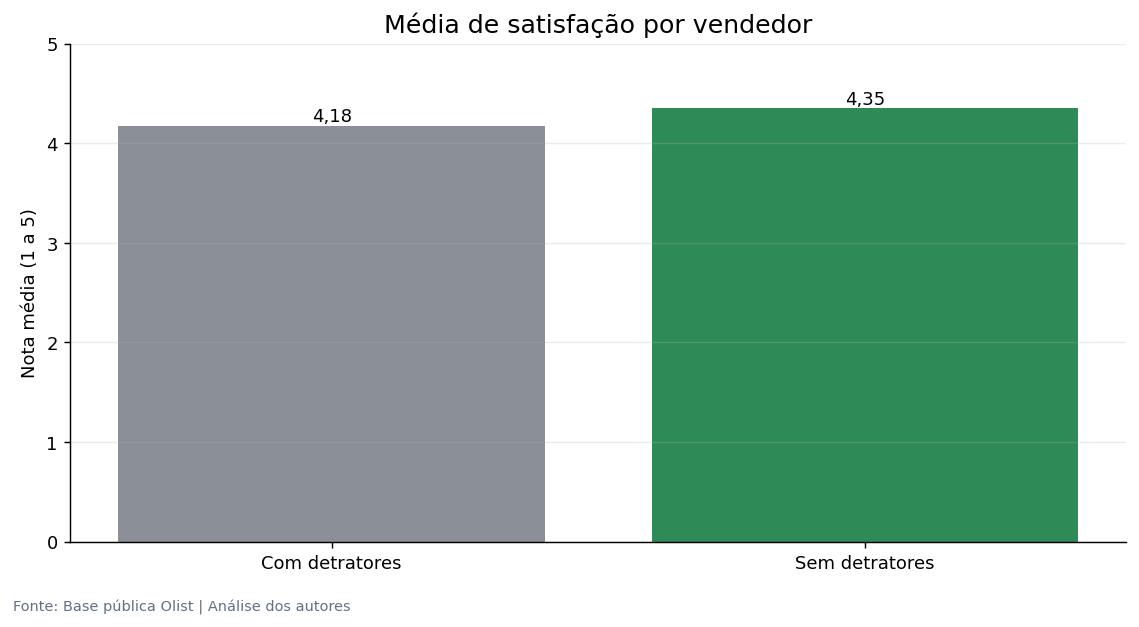

In [55]:
# Gráfico 4: compara a média de satisfação com e sem detratores.
# Essa visão mostra quanto o grupo crítico afeta a nota média por vendedor.
fig, ax = plt.subplots(figsize=(8.8, 4.8))
labels = ['Com detratores', 'Sem detratores']
values = [media_vendedor_com_detratores, media_vendedor_sem_detratores]

bars = ax.bar(labels, values, color=['#8A8F98', '#2E8B57'])
ax.set_title('Média de satisfação por vendedor')
ax.set_ylabel('Nota média (1 a 5)')
ax.set_ylim(0, 5)
ax.grid(axis='y', alpha=0.25)

# Mostra a nota média acima das barras, no formato brasileiro com vírgula.
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{value:.2f}'.replace('.', ','), ha='center', va='bottom')

add_footer(fig)
fig.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

### 7.5 Gráfico 5 - Distribuição por faixa de satisfação

Pergunta respondida: **quais grupos exigem remoção, alerta, monitoramento ou retenção?**

Este gráfico amplia a análise além da divisão binária entre detratores e não detratores. Ele organiza os vendedores em faixas de ação, permitindo separar casos críticos, casos de atenção, vendedores sem avaliação e parceiros saudáveis.

Essa leitura é a base para as recomendações finais, pois cada faixa pede uma decisão diferente.

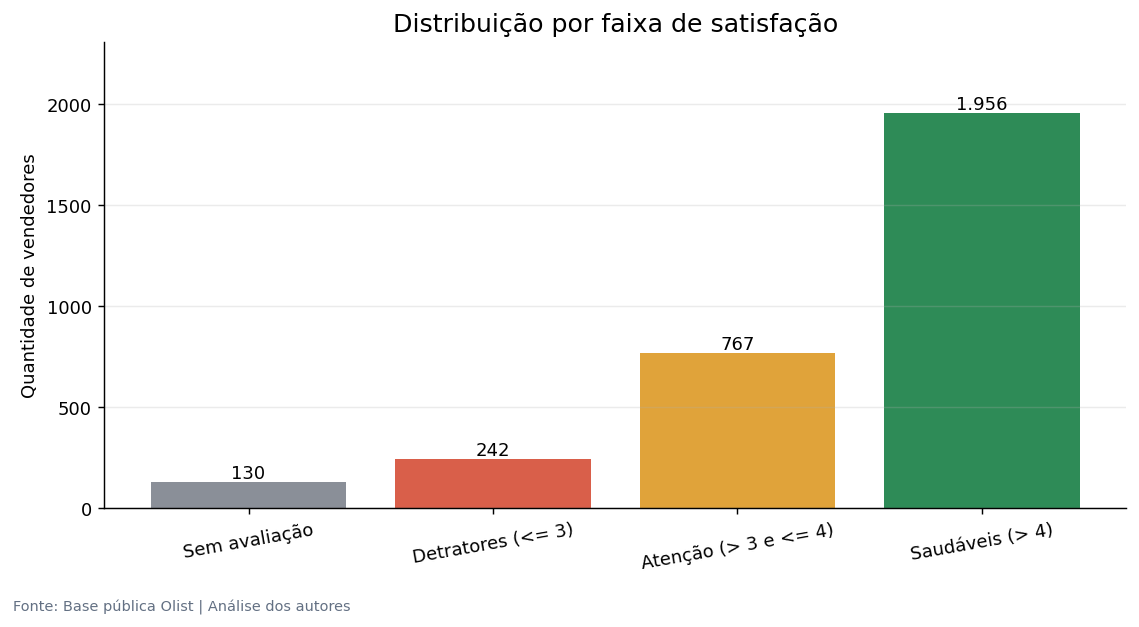

In [56]:
# Gráfico 5: mostra a distribuição dos vendedores por faixa de satisfação.
# Essa visualização apoia a recomendação de políticas diferentes por tipo de risco.
fig, ax = plt.subplots(figsize=(8.8, 4.8))
labels = faixa_satisfacao['faixa_satisfacao']
values = faixa_satisfacao['vendedores']

bars = ax.bar(labels, values, color=[COLORS[label] for label in labels])
ax.set_title('Distribuição por faixa de satisfação')
ax.set_ylabel('Quantidade de vendedores')
ax.grid(axis='y', alpha=0.25)
ax.set_ylim(0, values.max() * 1.18)
ax.tick_params(axis='x', rotation=10)

# Exibe a quantidade de vendedores em cada faixa para facilitar a leitura do plano de ação.
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), fmt_int(value), ha='center', va='bottom')

add_footer(fig)
fig.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

### 7.6 Gráfico 6 - Receita média por vendedor

Pergunta respondida: **qual grupo gera mais receita média por parceiro?**

Este gráfico compara a eficiência financeira média de cada grupo. Em vez de olhar apenas a receita total, ele mostra quanto um vendedor típico de cada grupo gera em média.

A análise ajuda a verificar se vendedores com melhor satisfação também apresentam melhor desempenho financeiro individual. Isso fortalece a ideia de que qualidade e retorno econômico caminham juntos na base analisada.

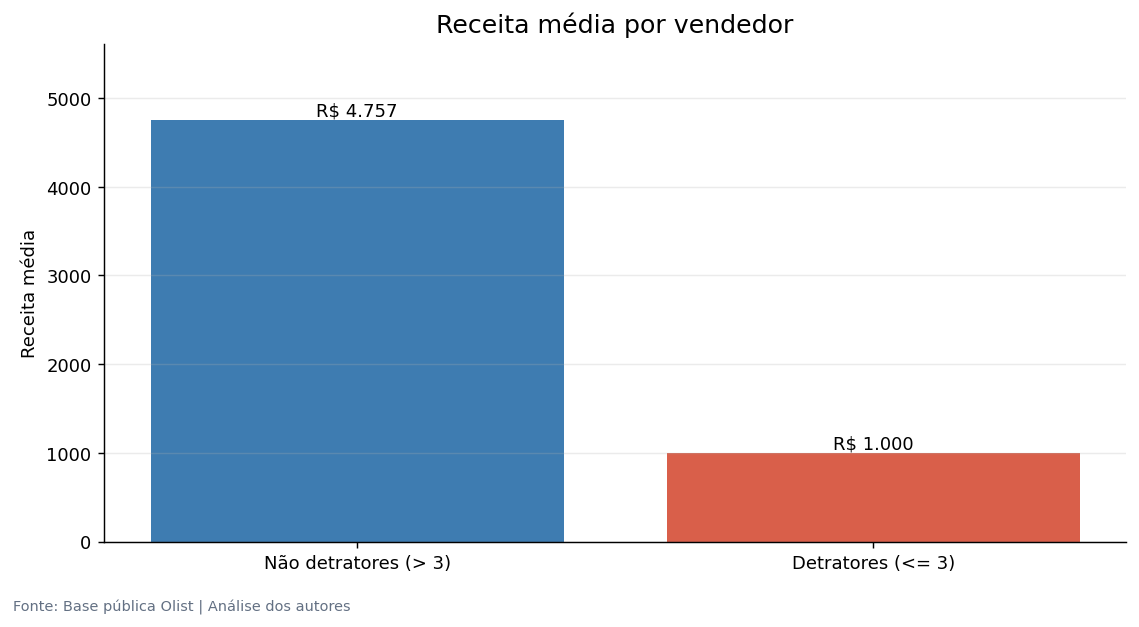

In [57]:
# Gráfico 6: compara a receita média por vendedor em cada grupo.
# Diferente da receita total, esta métrica mostra a eficiência média de cada parceiro.
fig, ax = plt.subplots(figsize=(8.8, 4.8))
labels = resumo_grupos['grupo_binario']
values = resumo_grupos['receita_media_vendedor']

bars = ax.bar(labels, values, color=[COLORS[label] for label in labels])
ax.set_title('Receita média por vendedor')
ax.set_ylabel('Receita média')
ax.grid(axis='y', alpha=0.25)
ax.set_ylim(0, values.max() * 1.18)

# Mostra o valor médio em reais acima de cada barra.
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), fmt_money(value), ha='center', va='bottom')

add_footer(fig)
fig.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

---

## 8. Conferência dos números usados no relatório

Esta etapa final funciona como uma auditoria dos principais números usados no documento. A célula reúne, em um único dicionário, as métricas que aparecem no relatório e nos gráficos.

A conferência ajuda a evitar divergências entre notebook, gráficos e texto final. Sempre que a base ou algum filtro for alterado, esta célula pode ser executada novamente para validar se os números do relatório continuam consistentes.

Os resultados exibidos aqui não geram novos arquivos. Eles servem como checagem interna e como apoio para revisão do grupo.

In [58]:
# ------------------- Conferência final dos indicadores -------------------
# Esta célula reúne os principais resultados usados no relatório.
# Ela serve como uma checagem rápida para evitar divergência entre texto, gráficos e notebook.

metrics = {
    # Quantidade de vendedores com dados consolidados de satisfação, pedidos e receita.
    'vendedores_analisados': int(len(seller_stats)),

    # Médias usadas na análise de impacto dos detratores.
    'media_com_detratores_por_vendedor': round(float(media_vendedor_com_detratores), 4),
    'media_sem_detratores_por_vendedor': round(float(media_vendedor_sem_detratores), 4),
    'media_com_detratores_por_avaliacao': round(float(media_avaliacao_com_detratores), 4),
    'media_sem_detratores_por_avaliacao': round(float(media_avaliacao_sem_detratores), 4),

    # Tabelas resumidas usadas nos gráficos e no texto executivo.
    'resumo_grupos': resumo_grupos.round(4).to_dict(orient='records'),
    'faixas_satisfacao': faixa_satisfacao.to_dict(orient='records'),
}

metrics

{'vendedores_analisados': 2970,
 'media_com_detratores_por_vendedor': 4.1754,
 'media_sem_detratores_por_vendedor': 4.3507,
 'media_com_detratores_por_avaliacao': 4.138,
 'media_sem_detratores_por_avaliacao': 4.153,
 'resumo_grupos': [{'grupo_binario': 'Não detratores (> 3)',
   'total_pedidos': 96920,
   'receita_total': 12978202.03,
   'vendedores': 2728,
   '% Receita': 98.1691,
   '% Pedidos': 99.0891,
   '% Vendedores': 91.8519,
   'receita_media_vendedor': 4757.4054},
  {'grupo_binario': 'Detratores (<= 3)',
   'total_pedidos': 891,
   'receita_total': 242046.9,
   'vendedores': 242,
   '% Receita': 1.8309,
   '% Pedidos': 0.9109,
   '% Vendedores': 8.1481,
   'receita_media_vendedor': 1000.1938}],
 'faixas_satisfacao': [{'faixa_satisfacao': 'Sem avaliação',
   'vendedores': 130},
  {'faixa_satisfacao': 'Detratores (<= 3)', 'vendedores': 242},
  {'faixa_satisfacao': 'Atenção (> 3 e <= 4)', 'vendedores': 767},
  {'faixa_satisfacao': 'Saudáveis (> 4)', 'vendedores': 1956}]}